In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import add_dummy_feature
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

### Solve by Normal Eq

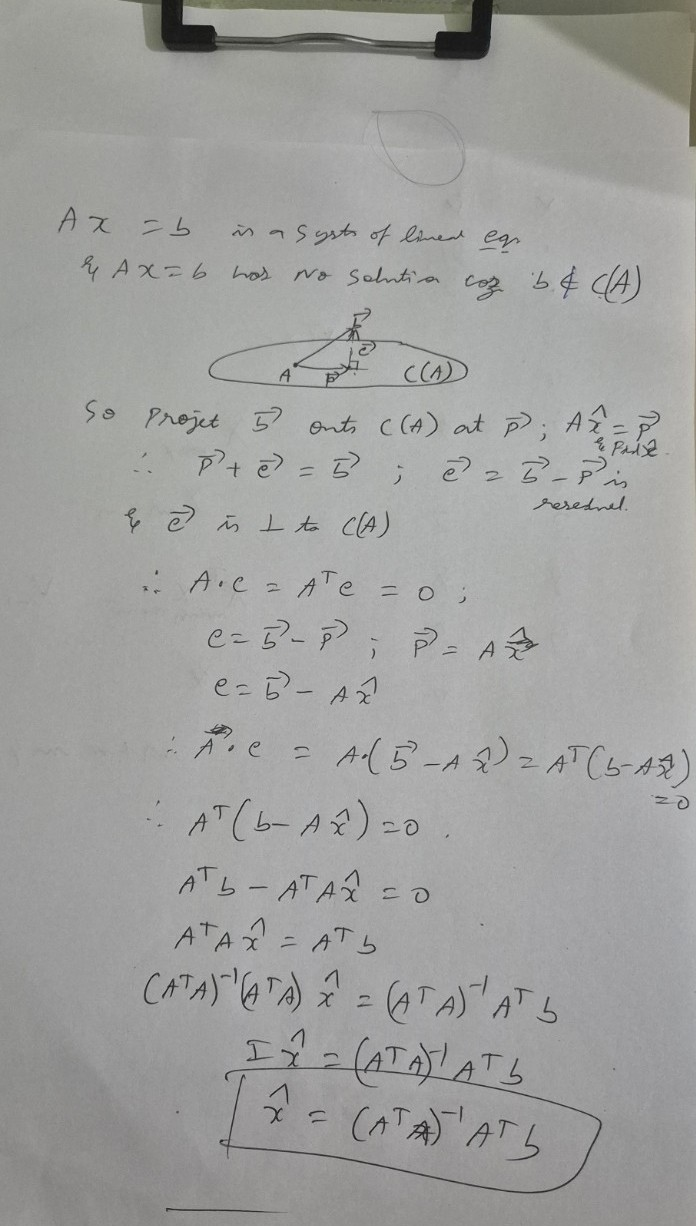

In [4]:
rng = np.random.default_rng(seed=42)
m = 200 # number of instances
X = 2 * rng.random((m, 1)) # column vector
X.shape, X

((200, 1),
 array([[1.5479121 ],
        [0.87775688],
        [1.71719584],
        [1.39473606],
        [0.1883547 ],
        [1.9512447 ],
        [1.5222794 ],
        [1.57212861],
        [0.25622727],
        [0.90077188],
        [0.74159605],
        [1.85352998],
        [1.28773024],
        [1.64552323],
        [0.8868284 ],
        [0.45447744],
        [1.10916957],
        [0.12763451],
        [1.65526234],
        [1.2633288 ],
        [1.51617548],
        [0.70905194],
        [1.94139605],
        [1.78624224],
        [1.55676699],
        [0.38927742],
        [0.93344201],
        [0.08760753],
        [0.30857898],
        [1.36609791],
        [1.48952431],
        [1.93501946],
        [0.65165072],
        [0.74091941],
        [0.93911162],
        [0.37894272],
        [0.25984301],
        [0.95140985],
        [0.4538187 ],
        [1.33962799],
        [0.87430384],
        [1.66535639],
        [1.4005302 ],
        [0.62473328],
        [1.6645196 ],

In [5]:
m_ = 3
c_ = 4
noise = rng.standard_normal((m, 1))
y = c_ + m_ * X + noise
y.shape, y

((200, 1),
 array([[ 9.28706309],
        [ 6.23866552],
        [ 9.14646565],
        [ 8.02076528],
        [ 4.90263864],
        [11.26121597],
        [ 8.65742312],
        [ 9.36032462],
        [ 2.7185097 ],
        [ 6.65359723],
        [ 5.38155788],
        [ 8.34177687],
        [ 6.98503835],
        [ 8.60244624],
        [ 7.57638774],
        [ 4.03703961],
        [ 7.35814021],
        [ 3.8987341 ],
        [ 8.63811394],
        [ 8.79274422],
        [ 9.08664188],
        [ 7.46455392],
        [ 9.66968247],
        [ 8.66278412],
        [ 8.44644217],
        [ 5.41032904],
        [ 6.97689938],
        [ 3.17843452],
        [ 5.01622673],
        [ 8.32652205],
        [10.98604697],
        [11.68190301],
        [ 5.1017088 ],
        [ 5.93537487],
        [ 5.35389287],
        [ 4.54612114],
        [ 5.09513404],
        [ 8.06008318],
        [ 4.63237226],
        [ 7.36473753],
        [ 4.47562248],
        [ 8.83340326],
        [ 7.1391762 ],


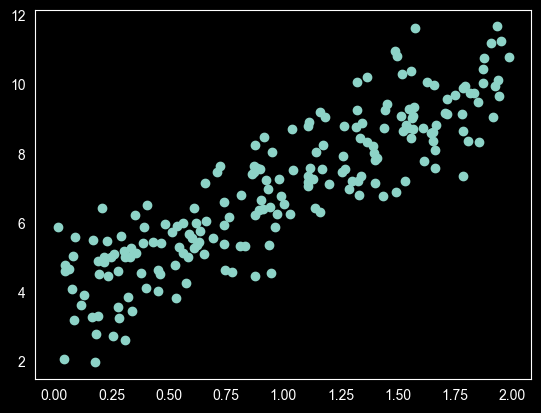

In [6]:
plt.scatter(X, y)
plt.grid()
plt.show()

In [7]:
X_b = add_dummy_feature(X) # add x0 = 1 to each instance
X_b.shape, X_b

((200, 2),
 array([[1.        , 1.5479121 ],
        [1.        , 0.87775688],
        [1.        , 1.71719584],
        [1.        , 1.39473606],
        [1.        , 0.1883547 ],
        [1.        , 1.9512447 ],
        [1.        , 1.5222794 ],
        [1.        , 1.57212861],
        [1.        , 0.25622727],
        [1.        , 0.90077188],
        [1.        , 0.74159605],
        [1.        , 1.85352998],
        [1.        , 1.28773024],
        [1.        , 1.64552323],
        [1.        , 0.8868284 ],
        [1.        , 0.45447744],
        [1.        , 1.10916957],
        [1.        , 0.12763451],
        [1.        , 1.65526234],
        [1.        , 1.2633288 ],
        [1.        , 1.51617548],
        [1.        , 0.70905194],
        [1.        , 1.94139605],
        [1.        , 1.78624224],
        [1.        , 1.55676699],
        [1.        , 0.38927742],
        [1.        , 0.93344201],
        [1.        , 0.08760753],
        [1.        , 0.30857898],
   

In [8]:
# (X.T x X).inv x X.t x y
# Shape : (2x200 . 200 x 2) x 2x200 x 200x1
#               2x2         x 2x200 x 200x1
#                          2x200    x 200x1
#                                  2x1  (Final Output Shape: m, c in mx+c)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
theta_best

array([[3.69084138],
       [3.32960458]])

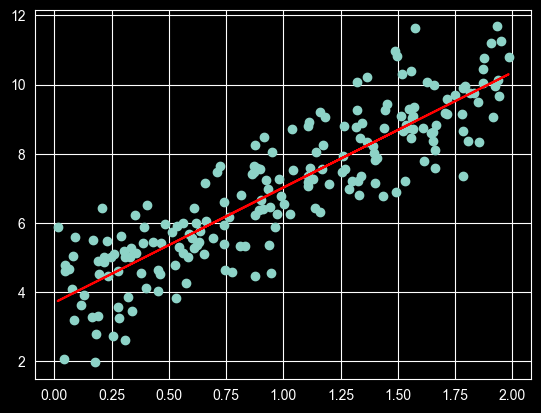

In [9]:
c__ = theta_best[0] # original = 4, Found = 3.690
m__ = theta_best[1] # Original = 3, Found = 3.329

# Plotline
plt.scatter(X, y)
plt.plot(X, m__*X + c__, "r")
plt.show()

In [10]:
X_new = np.array([[2]])
X_new_b = add_dummy_feature(X_new) # add x0 = 1 to each instance
y_predict = X_new_b @ theta_best
y_predict

array([[10.35005055]])

In [11]:
def predict(x):
    X_new = np.array([[x]])
    X_new_b = add_dummy_feature(X_new) # add x0 = 1 to each instance
    y_predict = X_new_b @ theta_best
    return y_predict

predict(1)

array([[7.02044597]])

In [12]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([3.69084138]), array([[3.32960458]]))

In [13]:
x = 1
X_new = np.array([[x]])
lin_reg.predict(X_new)

array([[7.02044597]])

In [14]:
theta_best, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best

array([[3.69084138],
       [3.32960458]])

In [15]:
residuals

array([199.16171014])

In [16]:
rank

np.int32(2)

In [17]:
s

array([20.71206939,  5.43847   ])

In [18]:
np.linalg.pinv(X_b)

array([[-3.72155550e-03,  6.71235696e-03, -6.35720125e-03,
        -1.33669698e-03,  1.74459331e-02, -1.00012009e-02,
        -3.32246993e-03, -4.09859201e-03,  1.63891981e-02,
         6.35402735e-03,  8.83229896e-03, -8.47984153e-03,
         3.29319056e-04, -5.24130190e-03,  6.57111890e-03,
         1.33025624e-02,  3.10940091e-03,  1.83913097e-02,
        -5.39293408e-03,  7.09234786e-04, -3.22743552e-03,
         9.33899115e-03, -9.84786325e-03, -7.43221209e-03,
        -3.85942090e-03,  1.43176875e-02,  5.84537311e-03,
         1.90145056e-02,  1.55741134e-02, -8.90818233e-04,
        -2.81249291e-03, -9.74858369e-03,  1.02326935e-02,
         8.84283378e-03,  5.75710062e-03,  1.44785925e-02,
         1.63329031e-02,  5.56562460e-03,  1.33128187e-02,
        -4.78697592e-04,  6.76611874e-03, -5.55009232e-03,
        -1.42690833e-03,  1.06517817e-02, -5.53706402e-03,
        -4.68088907e-03,  8.31289284e-03,  1.14003128e-02,
        -8.73584491e-04,  1.60267783e-02,  1.41536018e-0

In [19]:
np.linalg.pinv(X_b) @ y

array([[3.69084138],
       [3.32960458]])

### Solve by Gradient Descent

In [20]:
eta = 0.1
n_epochs = 300
m = len(X_b)


In [21]:
rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1)) # randomly initialized model parameters
theta

array([[ 0.30471708],
       [-1.03998411]])

In [22]:
for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta- y)
    theta = theta- eta * gradients

theta

array([[3.69086833],
       [3.32958134]])

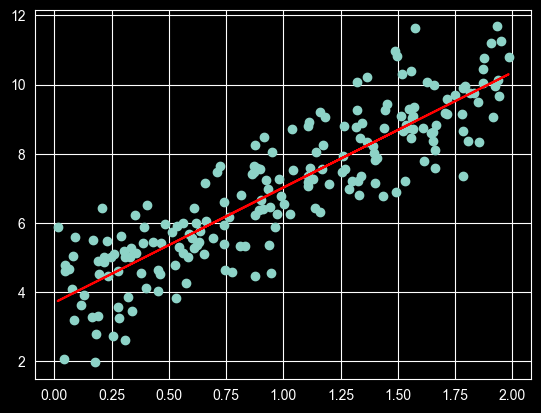

In [23]:
c__ = theta[0] # original = 4, Found = 3.690
m__ = theta[1] # Original = 3, Found = 3.329
plt.scatter(X, y)
plt.plot(X, m__*X + c__, "r")
plt.show()

In [24]:
n_epochs = 50
t0, t1 = 5, 50 # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))
theta

array([[ 0.30471708],
       [-1.03998411]])

In [39]:
for epoch in range(n_epochs):
    for data_index in range(m):
        random_index = rng.integers(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta- yi) # for SGD, do not divide by m
        eta = learning_schedule(epoch * m + data_index)
        theta = theta- eta * gradients

theta


array([[3.64572318],
       [3.36682643]])

In [54]:
for epoch in range(n_epochs):
    shuffled_indices = rng.permutation(m)
    for step, data_index in enumerate(shuffled_indices):
        xi = X_b[data_index:data_index + 1]
        yi = y[data_index:data_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * m + step)
        theta = theta - eta * gradients

theta

array([[3.69093117],
       [3.32915034]])

In [67]:
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01, n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, y.ravel())

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",1e-05
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [72]:
sgd_reg.intercept_, sgd_reg.coef_

(array([3.68899733]), array([3.33054574]))